In [2]:
import drawsvg as draw


## Left Tree


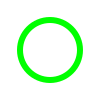

In [3]:
left = draw.Drawing(100, 100, origin='center')
left.append(draw.Circle(0, 0, 30, fill='none', stroke_width=6, stroke='lime'))
left.append(draw.Text('10', 16, 0, -10, center=True, fill='white'))
left.append(draw.Text('A', 16, 0, 12, center=True, fill='white'))

# left.save_svg('./imgs/trees/left_tree_row_1.svg')
left

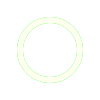

In [4]:
left = draw.Drawing(100, 100, origin='center')

left.append(draw.Circle(0, 0, 30, fill='none', stroke_width=6, stroke='lime'))
left.append(draw.Text('15', 16, 0, -10, center=True, fill='white'))
left.append(draw.Text('d', 16, 0, 12, center=True, fill='white'))

left.append(draw.Circle(0, 0, 30, fill='none', stroke_width=6, stroke='ivory'))
left.append(draw.Text('10', 16, 0, -10, center=True, fill='white'))
left.append(draw.Text('A', 16, 0, 12, center=True, fill='white'))

# left.save_svg('./imgs/trees/left_tree_row_2.svg')
left

## Right Tree


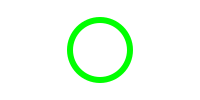

In [5]:
right = draw.Drawing(200, 100, origin='center')
right.append(draw.Circle(0, 0, 30, fill='none', stroke_width=6, stroke='lime'))
right.append(draw.Text('30', 16, 0, -10, center=True, fill='white'))
right.append(draw.Text('H', 16, 0, 12, center=True, fill='white'))


# right.save_svg('./imgs/trees/right_tree_row_1.svg')
right

None


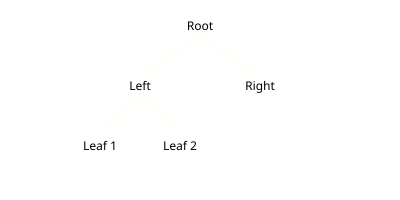

In [6]:
import xml.etree.ElementTree as ET

from IPython.display import SVG


class TreeNode:
    def __init__(self, name):
        self.name = name
        self.children = []


def build_svg_tree(node, x, y, dx, svg_root):
    # Draw node text
    text = ET.SubElement(
        svg_root,
        'text',
        x=str(x),
        y=str(y),
        attrib={'text-anchor': 'middle', 'font-family': 'sans-serif'},
    )
    text.text = node.name

    # Draw connections to children
    if node.children:
        num_children = len(node.children)
        start_x = x - (dx * (num_children - 1)) / 2
        for i, child in enumerate(node.children):
            child_x = start_x + i * dx
            child_y = y + 60
            # Draw line connection
            ET.SubElement(
                svg_root,
                'line',
                x1=str(x),
                y1=str(y + 5),
                x2=str(child_x),
                y2=str(child_y - 15),
                attrib={'stroke': 'ivory', 'stroke-width': '2'},
            )
            # Recursive call for child nodes
            build_svg_tree(child, child_x, child_y, dx / 1.5, svg_root)


# Setup tree
root = TreeNode('Root')
c1 = TreeNode('Left')
c2 = TreeNode('Right')
root.children = [c1, c2]
c1.children = [TreeNode('Leaf 1'), TreeNode('Leaf 2')]

# Create SVG Document container
# <svg xmlns="http://www.w3.org/2000/svg" width="400" height="200">
svg = ET.Element('svg', xmlns='http://www.w3.org/2000/svg', width='400', height='200')
build_svg_tree(root, 200, 30, 120, svg)

# Write out xml elements to an SVG file
tree = ET.ElementTree(svg)
# tree.write('pure_python_tree.svg')
print(ET.indent(svg))
SVG(ET.tostring(svg))

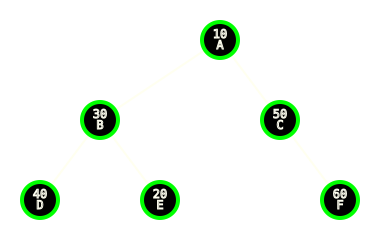

In [19]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Node:
    rank: int
    symbol: str
    left: Node | None = None
    right: Node | None = None


# 1. Assign x,y positions using an in-order traversal
def layout_tree(root: Node | None, x=0, y=0, x_step=60, y_step=80):
    positions = {}  # node -> (x, y)
    current_x = x

    def dfs(node: Node | None, depth: int):
        nonlocal current_x
        if not node:
            return
        dfs(node.left, depth + 1)
        positions[node] = (current_x, depth * y_step)
        current_x += x_step
        dfs(node.right, depth + 1)

    dfs(root, 0)
    return positions


# 2. Build SVG elements
def tree_to_svg(root: Node | None, radius=18) -> str:
    if not root:
        return "<svg xmlns='http://www.w3.org/2000/svg'></svg>"

    positions = layout_tree(root)
    nodes_svg: list[str] = []
    edges_svg: list[str] = []

    # edges
    for node, (x, y) in positions.items():
        for child in (node.left, node.right):
            if child:
                cx, cy = positions[child]
                edges_svg.append(
                    f"<line x1='{x}' y1='{y}' x2='{cx}' y2='{cy}' "
                    f"stroke='ivory' stroke-width='2' />"
                )

    # nodes
    for node, (x, y) in positions.items():
        nodes_svg.append(
            f"<circle cx='{x}' cy='{y}' r='{radius}' fill='black' stroke='lime' stroke-width='4'/>"
        )
        nodes_svg.append(
            f"<text x='{x}' y='{y - 2}' stroke='ivory' text-anchor='middle' "
            f"font-family='monospace' font-size='12'>{node.rank}</text>"
        )
        nodes_svg.append(
            f"<text x='{x}' y='{y + 9}' stroke='ivory' text-anchor='middle' "
            f"font-family='monospace' font-size='12'>{node.symbol}</text>"
        )

    # compute bounds
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    min_x, max_x = min(xs) - 40, max(xs) + 40
    min_y, max_y = min(ys) - 40, max(ys) + 40
    width = max_x - min_x
    height = max_y - min_y

    svg_content = '\n  '.join(edges_svg + nodes_svg)
    svg = (
        f"<svg xmlns='http://www.w3.org/2000/svg' "
        f"viewBox='{min_x} {min_y} {width} {height}' "
        f"width='{width}' height='{height}'>\n  {svg_content}\n</svg>"
    )
    return svg


# 3. Example usage
if __name__ == '__main__':
    # Build a small tree:
    #       A
    #      / \
    #     B   C
    #    / \   \
    #   D   E   F
    root = Node(
        10,
        'A',
        left=Node(30, 'B', Node(40, 'D'), Node(20, 'E')),
        right=Node(50, 'C', None, Node(60, 'F')),
    )

    svg = tree_to_svg(root)
    with open('tree.svg', 'w', encoding='utf-8') as f:
        f.write(svg)
display(SVG(svg))
